<a href="https://colab.research.google.com/github/anthoai97/sml-home-lab/blob/main/NLP_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import huggingface_hub

In [2]:
huggingface_hub.login()

In [3]:
!pip install trl accelerate gradio --quiet

In [4]:
# Set TOKENIZERS_PARALLELISM = "false" to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Base imports
import transformers
import trl # trl = Transformers Reinforcement Learning -> https://github.com/huggingface/trl
import datasets
import accelerate

import gradio as gr

In [5]:
# Check the amount of GPU memory available (we need at least ~16GB)
# CUDA = NVIDIA GPU backend
# MPS = macOS Metal Performance Shaders backend (Apple Silicon)
# Note: Training on macOS/MPS is significantly slower than on CUDA/NVIDIA GPUs.
# MPS is fine for learning, experimentation and inference, but expect longer training times.
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

if DEVICE == "cuda":
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)

    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory

    print(f"Backend: CUDA")
    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")

elif DEVICE == "mps":
    # Note: MPS doesn't expose detailed memory stats like CUDA.
    # Apple Silicon uses unified memory (shared between CPU and GPU).
    # You can check total system memory as a proxy.
    import subprocess
    total_memory = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).strip())

    print(f"Backend: MPS")
    print(f"Device: Apple Silicon (Metal Performance Shaders)")
    print(f"Total System Memory (unified): {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")

    # Verify MPS works with a quick tensor test
    x = torch.tensor([1.0, 2.0]).to("mps")
    print(f"MPS tensor test: {x.device}")

else:
    print("No GPU available (no CUDA or MPS backend found)")

Using device: cuda
Backend: CUDA
GPU: Tesla T4
Total Memory:     15637.09 MB | 15.64 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      15637.09 MB | 15.64 GB


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-3-270m-it" # note: "it" stands for "instruction tuned" which means the model has been tuned for following instructions

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto", # put the model on the GPU
    attn_implementation="eager" # could use flash_attention_2 but ran into issues... so stick with Eager for now
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


In [7]:
tokenizer("Hello my name is Daniel")

{'input_ids': [2, 9259, 1041, 1463, 563, 13108], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [8]:
import torch

input_string = "Hello my name is Andy"
print(f"[INFO] Input string: {input_string}")

token_tensor = torch.tensor(tokenizer(input_string)["input_ids"]).unsqueeze(0).to(DEVICE)
print(f"[INFO] Token tensor shape: {token_tensor.shape}")
print(f"[INFO] Token tensor dtype: {token_tensor.dtype}")
print(f"[INFO] Token tensor device: {token_tensor.device}")
print(f"[INFO] Token tensor: {token_tensor}")

outputs = model(token_tensor)
outputs.keys()


[INFO] Input string: Hello my name is Andy
[INFO] Token tensor shape: torch.Size([1, 6])
[INFO] Token tensor dtype: torch.int64
[INFO] Token tensor device: cuda:0
[INFO] Token tensor: tensor([[    2,  9259,  1041,  1463,   563, 26650]], device='cuda:0')


odict_keys(['logits', 'past_key_values'])

In [9]:
# Get the logits shape
logits = outputs.logits
print(f"[INFO] Logits shape: {logits.shape}")

[INFO] Logits shape: torch.Size([1, 6, 262144])


In [10]:
# Get the predicted token IDs by taking argmax over the vocab dimension
predicted_ids = outputs.logits.argmax(dim=-1)  # shape: [1, seq_len]
print(f"[INFO] Predicted token IDs shape: {predicted_ids.shape}")
print(f"[INFO] Predicted token IDs: {predicted_ids}")

# Decode back to text
predicted_tokens = tokenizer.convert_ids_to_tokens(predicted_ids[0])
predicted_text = tokenizer.decode(predicted_ids[0])

print(f"[INFO] Token IDs: {predicted_ids[0].tolist()}")
print(f"[INFO] Tokens: {predicted_tokens}")
print(f"[INFO] Decoded text: {predicted_text}")

print(f"\n[INFO] Original input string: {input_string}")

[INFO] Predicted token IDs shape: torch.Size([1, 6])
[INFO] Predicted token IDs: tensor([[  1106, 236888,   4389,    563,    870, 236764]], device='cuda:0')
[INFO] Token IDs: [1106, 236888, 4389, 563, 870, 236764]
[INFO] Tokens: ['import', '!', '▁friend', '▁is', '▁[', ',']
[INFO] Decoded text: import! friend is [,

[INFO] Original input string: Hello my name is Andy


In [11]:
def get_model_num_params(model):
    """
    Returns the number of trainable, non-trainable and total parameters of a PyTorch model.
    """
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params
    return {"trainable_params": trainable_params,
            "non_trainable_params": non_trainable_params,
            "total_params": total_params}

# Get parameters of our fine-tuned model
model_params = get_model_num_params(model)
print(f"Trainable parameters: {model_params['trainable_params']:,}")
print(f"Non-trainable parameters: {model_params['non_trainable_params']:,}")
print(f"Total parameters: {model_params['total_params']:,}")

Trainable parameters: 268,098,176
Non-trainable parameters: 0
Total parameters: 268,098,176


In [12]:
gpt_oss_120b_parameter_count = 120_000_000_000
gemma_3_270m_parameter_count = model_params['total_params']

parameter_ratio = gpt_oss_120b_parameter_count / gemma_3_270m_parameter_count

print(f"[INFO] Gemma 3 270M is {parameter_ratio:.2f}x smaller than gpt-oss-120b.")

[INFO] Gemma 3 270M is 447.60x smaller than gpt-oss-120b.


In [13]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

[INFO] Number of samples in the dataset: 1420


In [14]:
import ast
import random

def get_random_idx(dataset):
    """Returns a random integer index based on the number of samples in the dataset."""
    random_idx = random.randint(0, len(dataset)-1)
    return random_idx

random_idx = get_random_idx(dataset["train"])
random_sample = dataset["train"][random_idx]

example_input = random_sample["sequence"]
example_output = random_sample["gpt-oss-120b-label"]
example_output_condensed = random_sample["gpt-oss-120b-label-condensed"]

print(f"[INFO] Input:\n{example_input}\n")
print()
print(f"[INFO] Example structured JSON output (what we want to turn our raw texts into):\n")
print(ast.literal_eval(example_output)) # ast.literal_eval turns the string into JSON
print()
print(f"[INFO] Example output condensed (we'll train our model to predict the condensed output since it uses less tokens than JSON):\n")
print(example_output_condensed)

[INFO] Input:
CJ Food Andu Ginger Flavoured Dumplings Nutrition Information: Servings per package: About 2, Serving size: 129 g (6 pieces). Average Quantity per serving: Energy 1000 kJ (240 kcal), Protein 7.2 g, Fat total 14.2 g (saturated 2.7 g), Carbohydrate 21.0 g (sugars 1.2 g), Sodium 409 mg. Average Quantity per 100 g: Energy 778 kJ (186 kcal), Protein 7.2 g, Fat total 5.6 g (saturated 11.0 g), Carbohydrate 2.1 g (sugars 16.3 g), Sodium 317 mg. Ingredients: Fish Gelatin, Seasoning (Yeast Extract, Salt, Soy Sauce), Flavour Enhancer, Wheat Flour, Canola Oil, Palm Shortening, Texturized Soy, Water, Modified Tapioca Starch, Protein, Tofu, Onion, Cabbage, Ginger, Wheat Fibre, Garlic, Thickener, Spring Onion, Leek, Soy Sauce, Hot Pepper Extract, Flavour Enhancers, Salt, Sugar, Artificial Flavour, Black Pepper Powder, Ginger Powder, Seasoning, Thickener, Natural Flavour. Contains: Fish, Soy, Wheat, Gluten. May contain: Crustacean, Egg, Milk, Mollusc, Peanut, Sesame, Tree nuts, Sulphites

In [15]:
# Our fine-tuned model will assign tags to text so we can easily filter them by type in the future
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient_list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}

In [16]:
def sample_to_conversation(sample):
    """Helper function to convert an input sample to prompt-completion style."""
    return {
        "prompt": [
            {"role": "user", "content": sample["sequence"]} # Load the sequence from the dataset
        ],
        "completion": [
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]} # Load the gpt-oss-120b generated label
        ]
    }

sample_to_conversation(random_sample)

{'prompt': [{'role': 'user',
   'content': 'CJ Food Andu Ginger Flavoured Dumplings Nutrition Information: Servings per package: About 2, Serving size: 129 g (6 pieces). Average Quantity per serving: Energy 1000 kJ (240 kcal), Protein 7.2 g, Fat total 14.2 g (saturated 2.7 g), Carbohydrate 21.0 g (sugars 1.2 g), Sodium 409 mg. Average Quantity per 100 g: Energy 778 kJ (186 kcal), Protein 7.2 g, Fat total 5.6 g (saturated 11.0 g), Carbohydrate 2.1 g (sugars 16.3 g), Sodium 317 mg. Ingredients: Fish Gelatin, Seasoning (Yeast Extract, Salt, Soy Sauce), Flavour Enhancer, Wheat Flour, Canola Oil, Palm Shortening, Texturized Soy, Water, Modified Tapioca Starch, Protein, Tofu, Onion, Cabbage, Ginger, Wheat Fibre, Garlic, Thickener, Spring Onion, Leek, Soy Sauce, Hot Pepper Extract, Flavour Enhancers, Salt, Sugar, Artificial Flavour, Black Pepper Powder, Ginger Powder, Seasoning, Thickener, Natural Flavour. Contains: Fish, Soy, Wheat, Gluten. May contain: Crustacean, Egg, Milk, Mollusc, Peanut

In [17]:
# Map our sample_to_conversation function to dataset
dataset = dataset.map(sample_to_conversation,
                      batched=False)

dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

In [18]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

In [19]:
def create_easy_sample(input):
    template = {"role": "user", "content": input}
    return template

create_easy_sample(input="Hello, I'm Andy!")

{'role': 'user', 'content': "Hello, I'm Andy!"}

In [20]:
from transformers import pipeline

# Load model and use it as a pipeline
print(f"[INFO] Creating pipeline with model: {MODEL_NAME}\n")
pipe = pipeline("text-generation",
                model=model,
                tokenizer=tokenizer)

input_text = "Hi my name is Andy. Please reply to me with a machine learning poem."
print(f"[INFO] This is the raw text input:\n{input_text}\n")

# Prepare the sample and tokenize
easy_sample = create_easy_sample(input=input_text)
input_prompt = pipe.tokenizer.apply_chat_template([easy_sample], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)
# Pass the prepared input prompt through the pipeline
default_outputs = pipe(input_prompt,
                       max_new_tokens=512,
                       disable_compile=True)

print(f"[INFO] This is the input prompt: {input_prompt}")
print(f"[INFO] Output from {MODEL_NAME}:")
print(default_outputs[0]["generated_text"][len(input_prompt):])

[INFO] Creating pipeline with model: google/gemma-3-270m-it

[INFO] This is the raw text input:
Hi my name is Andy. Please reply to me with a machine learning poem.



Passing `generation_config` together with generation-related arguments=({'disable_compile', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] This is the input prompt: <bos><start_of_turn>user
Hi my name is Andy. Please reply to me with a machine learning poem.<end_of_turn>
<start_of_turn>model

[INFO] Output from google/gemma-3-270m-it:
I'm Andy, and I'm ready to help you craft a machine learning poem! Tell me what you'd like me to write. I can come up with:
*   A simple, catchy rhyme or rhythm
*   A more complex, metaphorical poem
*   A descriptive poem about a specific topic
*   A poem that explores a specific emotion or feeling
*   A poem that uses metaphors and similes

Let's start with a general poem, or you can tell me what kind of poem you're looking for!


In [21]:
print(tokenizer.chat_template)

{{ bos_token }}
{%- if messages[0]['role'] == 'system' -%}
    {%- if messages[0]['content'] is string -%}
        {%- set first_user_prefix = messages[0]['content'] + '

' -%}
    {%- else -%}
        {%- set first_user_prefix = messages[0]['content'][0]['text'] + '

' -%}
    {%- endif -%}
    {%- set loop_messages = messages[1:] -%}
{%- else -%}
    {%- set first_user_prefix = "" -%}
    {%- set loop_messages = messages -%}
{%- endif -%}
{%- for message in loop_messages -%}
    {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
        {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
    {%- endif -%}
    {%- if (message['role'] == 'assistant') -%}
        {%- set role = "model" -%}
    {%- else -%}
        {%- set role = message['role'] -%}
    {%- endif -%}
    {{ '<start_of_turn>' + role + '
' + (first_user_prefix if loop.first else "") }}
    {%- if message['content'] is string -%}
        {{ message['content'] | trim }}


In [22]:
# Get a random sample
random_idx = get_random_idx(dataset["train"])
random_train_sample = dataset["train"][random_idx]
raw_text_input = random_train_sample["sequence"]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["prompt"],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input (raw text):\n{raw_text_input}\n")
print(f"[INFO] Input (prompt formatted):\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input (raw text):
This black and white photograph captures the serene yet dramatic beauty of a mountaintop bathed in the ethereal glow of a full moon. Dominating the center of the image, the large gray mountain stands imposingly with its summit brightly illuminated by the moon's silver light, in stark contrast to its darker, shadowed base. Snow accentuates the mountain's barren, rugged contours. The background sky is an inky expanse devoid of stars, heightening the sense of isolation and tranquility. In the foreground, two smaller, darker mountains frame the scene, their heights dwarfed by the majestic peak behind them. The high-quality, polished appearance of the photograph showcases the detailed interplay of light and shadow, inviting viewers to question its authenticity in a world where digital manipulation blurs the lines between reality and art.

[INFO] Input (prompt formatted):
<bos><start_of_turn>user
This black and white photograph captures the serene yet dramatic beauty

In [23]:
prompt_instruction = """Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: <targ_input_text>"""

def update_input_message_content(input):
    """Helper function to format our prompt with target input text from a given message sample."""
    original_content = input["prompt"][0]["content"]
    new_content = prompt_instruction.replace("<targ_input_text>", original_content)

    new_input = [{"content": new_content,
                  "role": "user"}]

    return new_input

print(f'[INFO] Original content:\n{random_train_sample["prompt"][0]["content"]}')
print()
print(f'[INFO] New content with instructions in prompt:')
print(update_input_message_content(input=random_train_sample)[0]["content"])

[INFO] Original content:
This black and white photograph captures the serene yet dramatic beauty of a mountaintop bathed in the ethereal glow of a full moon. Dominating the center of the image, the large gray mountain stands imposingly with its summit brightly illuminated by the moon's silver light, in stark contrast to its darker, shadowed base. Snow accentuates the mountain's barren, rugged contours. The background sky is an inky expanse devoid of stars, heightening the sense of isolation and tranquility. In the foreground, two smaller, darker mountains frame the scene, their heights dwarfed by the majestic peak behind them. The high-quality, polished appearance of the photograph showcases the detailed interplay of light and shadow, inviting viewers to question its authenticity in a world where digital manipulation blurs the lines between reality and art.

[INFO] New content with instructions in prompt:
Given the following target input text from an image caption, please extract the f

In [24]:
# Apply the chat template
updated_input_prompt = update_input_message_content(input=random_train_sample)

input_prompt = pipe.tokenizer.apply_chat_template(conversation=updated_input_prompt,
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt,
                       max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input:
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: This black and white photograph captures the serene yet dramatic beauty of a mountaintop bathed in the ethereal glow of a full moon. Dominating the center of the image, the large gray mountain stands imposingly with its summit brightly illuminated by the moon's silver light,

In [25]:
random_train_sample

{'sequence': "This black and white photograph captures the serene yet dramatic beauty of a mountaintop bathed in the ethereal glow of a full moon. Dominating the center of the image, the large gray mountain stands imposingly with its summit brightly illuminated by the moon's silver light, in stark contrast to its darker, shadowed base. Snow accentuates the mountain's barren, rugged contours. The background sky is an inky expanse devoid of stars, heightening the sense of isolation and tranquility. In the foreground, two smaller, darker mountains frame the scene, their heights dwarfed by the majestic peak behind them. The high-quality, polished appearance of the photograph showcases the detailed interplay of light and shadow, inviting viewers to question its authenticity in a world where digital manipulation blurs the lines between reality and art.",
 'image_url': 'https://i0.wp.com/cuchara.photography/wp-content/uploads/2022/04/js_20201128_09665-enhanced-hdr.jpg?resize=1024%2C1024&ssl=1

In [26]:
# This is our input
print(f"[INFO] Raw text input:")
print(random_train_sample["prompt"][0]["content"])
print()

# This is our ideal output:
print(f"[INFO] Ideal extraction output:")
print(random_train_sample["completion"][0]["content"])

[INFO] Raw text input:
This black and white photograph captures the serene yet dramatic beauty of a mountaintop bathed in the ethereal glow of a full moon. Dominating the center of the image, the large gray mountain stands imposingly with its summit brightly illuminated by the moon's silver light, in stark contrast to its darker, shadowed base. Snow accentuates the mountain's barren, rugged contours. The background sky is an inky expanse devoid of stars, heightening the sense of isolation and tranquility. In the foreground, two smaller, darker mountains frame the scene, their heights dwarfed by the majestic peak behind them. The high-quality, polished appearance of the photograph showcases the detailed interplay of light and shadow, inviting viewers to question its authenticity in a world where digital manipulation blurs the lines between reality and art.

[INFO] Ideal extraction output:
food_or_drink: 0
tags: 
foods: 
drinks:


In [29]:
# Setting up our SFTConfig
from trl import SFTConfig

torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5
BATCH_SIZE = 4 # Change this depending on the VRAM you have available

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

# Setup SFTConfig
sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512, # Captions/texts longer than this (in tokens) will be shortened to 512
    packing=False,
    num_train_epochs=3, # Number of times our model will pass through all of the training data (you can alter this if you like)
    per_device_train_batch_size=BATCH_SIZE, # Note: you can change this depending on the amount of VRAM your GPU has
    per_device_eval_batch_size=BATCH_SIZE,
    completion_only_loss=True, # we want our model to only learn how to *complete* / generate the output tokens given the input tokens
    gradient_checkpointing=False,
    optim="adamw_torch_fused", # Note: if you try "adamw", you will get an error
    logging_steps=1,
    save_strategy="epoch", # Save our model every epoch
    eval_strategy="epoch", # Evaluate our model every epoch
    learning_rate=BASE_LEARNING_RATE,
    fp16=(torch_dtype == torch.float16),
    bf16=(torch_dtype == torch.bfloat16),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=True,
    lr_scheduler_type="constant",
    push_to_hub=False, # Optionally push our model directly to Hugging Face Hub
    report_to="none" # Optionally save our models training metrics to a logging service
)

# There are a lot of settings in the sft_config, so feel free to uncomment this and inspect it if you want
sft_config

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


SFTConfig(output_dir='./checkpoint_models', do_train=False, do_eval=True, do_predict=False, eval_strategy=<IntervalStrategy.EPOCH: 'epoch'>, prediction_loss_only=False, per_device_train_batch_size=4, per_device_eval_batch_size=4, gradient_accumulation_steps=1, eval_accumulation_steps=None, eval_delay=0, torch_empty_cache_steps=None, learning_rate=5e-05, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=3, max_steps=-1, lr_scheduler_type=<SchedulerType.CONSTANT: 'constant'>, lr_scheduler_kwargs=None, warmup_ratio=None, warmup_steps=0, log_level='passive', log_level_replica='warning', log_on_each_node=True, logging_dir=None, logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_first_step=False, logging_steps=1, logging_nan_inf_filter=True, save_strategy=<SaveStrategy.EPOCH: 'epoch'>, save_steps=500, save_total_limit=None, enable_jit_checkpoint=False, save_on_each_node=False, save_only_model=False, restore_callback_states_fr

In [30]:
# Supervised Fine-Tuning = provide input and desired output samples
from trl import SFTTrainer

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)

# Fine-tune our model and save the training artifacts
training_ouput = trainer.train()

Epoch,Training Loss,Validation Loss
1,0.527375,0.086953
2,0.033494,0.097853
3,0.104115,0.108953


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


In [31]:
eval_metrics = trainer.evaluate()

print(f"[INFO] Eval metrics:")
eval_metrics

[INFO] Eval metrics:


{'eval_loss': 0.10895323753356934,
 'eval_runtime': 26.0688,
 'eval_samples_per_second': 10.894,
 'eval_steps_per_second': 2.724}

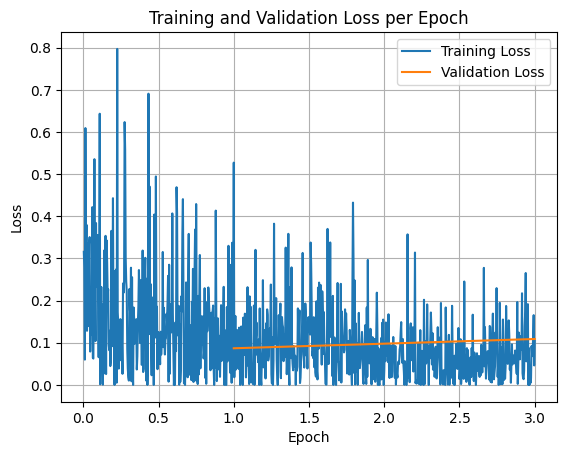

In [32]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Save the model
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
!ls ./checkpoint_models/

chat_template.jinja  config.json	     tokenizer_config.json
checkpoint-284	     generation_config.json  tokenizer.json
checkpoint-568	     model.safetensors	     training_args.bin
checkpoint-852	     README.md


In [35]:
# Optional: Remove all the checkpoint folders (since we've already saved the best model)
!rm -rf ./checkpoint_models/checkpoint-*/*
!rm -rf ./checkpoint_models/checkpoint-*

In [36]:
!ls checkpoint_models/

chat_template.jinja	model.safetensors      tokenizer.json
config.json		README.md	       training_args.bin
generation_config.json	tokenizer_config.json


In [37]:
# Load the fine-tuned model and see how it goes
from transformers import AutoTokenizer, AutoModelForCausalLM

CHECKPOINT_DIR_NAME = "./checkpoint_models"

print(f"[INFO] Loading in model from: {CHECKPOINT_DIR_NAME}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
)

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

# Check our loaded model (it's the same architecture as before except this time with updated weights)
loaded_model

[INFO] Loading in model from: ./checkpoint_models


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

In [38]:
from transformers import pipeline

loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

TextGenerationPipeline: {'model': 'Gemma3ForCausalLM', 'dtype': 'bfloat16', 'device': 'cuda', 'input_modalities': ('image', 'text'), 'output_modalities': ('text',)}

In [39]:
# Get a random sample
import random

random_test_idx = random.randint(0, len(dataset["test"])-1)
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=random_test_sample["prompt"],
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output):\n{random_test_sample['gpt-oss-120b-label-condensed']}")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Test sample input:
<bos><start_of_turn>user
The image shows a package of "Helpful Harvest" dried vegetables. The ingredients include a variety of vegetables such as zucchini, carrots, mushrooms, onions, capsicum, and celery. The product is made from 100% vegetables and includes wonky and overly abundant produce where possible. The package notes that the ingredients and percentages may differ due to seasonal availability.

The allergens listed are milk, eggs, soy, sesame seeds, hazelnuts, pistachios, cashews, and almonds. The nutrition information indicates that the package contains 4 servings, with each serving size being 10g. The average quantities per serving are as follows:
- Energy: 125 kJ
- Protein: 1.9 g
- Gluten: 0 g (marked as gluten-free)
- Fat, total: 0.3 g
- Saturated fat: 0 g
- Carbohydrate: 3.4 g
- Sugars: 3.4 g
- Fibre: 3.4 g
- Sodium: 2.1 g

The average quantities per 100g are:
- Energy: 1250 kJ
- Protein: 18.7 g
- Fat, total: 2.8 g
- Saturated fat: 0 g
- Carbohyd

In [40]:
# Test the loaded model on raw text (this won't work as well as formatted text)
test_input_message_without_formatting = "Hello my name is Daniel!"
loaded_model_pipeline(test_input_message_without_formatting)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello my name is Daniel!\nfood_or_drink: 0\ntags: \nfoods: \ndrinks:'}]

In [41]:
def format_message(input):
    return [{"role": "user", "content": input}]

test_input_message_with_formatting = format_message(input=test_input_message_without_formatting)
test_input_message_with_formatting

[{'role': 'user', 'content': 'Hello my name is Daniel!'}]

In [42]:
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=test_input_message_with_formatting,
                                                                   tokenize=False,
                                                                   add_generation_prompt=True)

input_prompt

'<bos><start_of_turn>user\nHello my name is Daniel!<end_of_turn>\n<start_of_turn>model\n'

In [43]:
loaded_model_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                             max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{loaded_model_outputs[0]['generated_text'][len(input_prompt):]}")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input:
<bos><start_of_turn>user
Hello my name is Daniel!<end_of_turn>
<start_of_turn>model


[INFO] Output:
food_or_drink: 0
tags: 
foods: 
drinks:


In [44]:
import time

def pred_on_text(input_text):
    start_time = time.time()

    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

example_input_text = "British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"
output_text, output_raw, output_total_time = pred_on_text(input_text=example_input_text)

print(f"[INFO] Input text:\n{example_input_text}\n")
print(f"[INFO] Model generated output text:\n{output_text}\n")
print(f"[INFO] Model full raw output:\n{output_raw}\n")
print(f"[INFO] Inference time:\n{output_total_time}\n")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input text:
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes

[INFO] Model generated output text:
food_or_drink: 1
tags: fi, di
foods: baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, fried tomatoes
drinks: tea

[INFO] Model full raw output:
[{'generated_text': [{'role': 'user', 'content': 'British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes'}, {'role': 'assistant', 'content': 'food_or_drink: 1\ntags: fi, di\nfoods: baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, fried tomatoes\ndrinks: tea'}]}]

[INFO] Inference time:
2.7101



In [45]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# Change this to your own
HF_USERNAME = "anquachdev"

# Create the repo (this is in the format [Hugging Face Username]/[Target Model Name])
repo_id = f"{HF_USERNAME}/FoodExtract-gemma-3-270m-fine-tune-v1"

# Create the repo
create_repo(repo_id,
            repo_type="model",
            private=False, # optionally make the repo private if you'd like to upload sensitive information
            exist_ok=True)

RepoUrl('https://huggingface.co/anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1')

In [46]:
model_readme = r"""---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---

# FoodExtract-v1

This is a food and drink extraction language model built on [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Given raw text, it's designed to:

1. Classify the text into food or drink (e.g. "a photo of a dog" = not food or drink, "a photo of a pizza" = food or drink).
2. Tag the text with one or more tags (see tags_dict below).
3. Extract the edible food-related items as a list.
4. Extract the edible drink-related items as a list.

For example, the input text might be:

```
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes
```

And the model will generate:

```
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea
```

This model can be used for filtering a large image caption (e.g. [DataComp-1B](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B)) text dataset for food and drink related items.

## Dataset

The model was trained on the [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.

This dataset contains 1400 samples of raw text and JSON output pairs of structured food extractions provided by `gpt-oss-120b`.

For example, a raw image caption input might be:

```
another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky
```

And the `gpt-oss-120b` generated output (JSON) would be:

```
{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}
```

This is condensed to:

```
food_or_drink: 0\ntags: \nfoods: \ndrinks:
```

### Tags dictionary mapping

These tags are designed for fast filtering.

For example, the model can assign a certain tag based on what's in the raw text and then we can filter for "ingredient list" items.

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

## Helper functions

The model is trained to output a condensed version of the structured data.

We do this so the model can generate less tokens (e.g. it doesn't have to generate JSON outputs).

The following functions help to condense and uncondense raw text outputs/inputs into the desired structure.

```python
def condense_output(original_output):
    '''Helper function to condense a given FoodExtract string.

    Example input: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}

    Example output: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:'''

    condensed_output_string_base = '''food_or_drink: <is_food_or_drink>
    tags: <output_tags>
    foods: <food_items>
    drinks: <drink_items>'''

    is_food_or_drink = str(1) if str(original_output["is_food_or_drink"]).lower() == "true" else str(0)
    tags = ", ".join(original_output["tags"]) if len(original_output["tags"]) > 0 else ""
    foods = ", ".join(original_output["food_items"]) if len(original_output["food_items"]) > 0 else ""
    drinks = ", ".join(original_output["drink_items"]) if len(original_output["drink_items"]) > 0 else ""

    condensed_output_string_formatted = condensed_output_string_base.replace("<is_food_or_drink>", is_food_or_drink).replace("<output_tags>", tags).replace("<food_items>", foods).replace("<drink_items>", drinks)

    return condensed_output_string_formatted.strip()

def uncondense_output(condensed_output):
    '''Helper to go from condensed output to uncondensed output.

    Example input: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:

    Example output: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}
    '''

    condensed_list = condensed_output.split("\n")

    condensed_dict_base = {
        "is_food_or_drink": "",
        "tags": [],
        "food_items": [],
        "drink_items": []
    }

    # Set values to defaults
    food_or_drink_item = None
    tags_item = None
    foods_item = None
    drinks_item = None

    # Extract items from condensed_list
    for item in condensed_list:
        if "food_or_drink:" in item.strip():
            food_or_drink_item = item

        if "tags:" in item:
            tags_item = item

        if "foods:" in item:
            foods_item = item

        if "drinks:" in item:
            drinks_item = item

    if food_or_drink_item:
        is_food_or_drink_bool = True if food_or_drink_item.replace("food_or_drink: ", "").strip() == "1" else False
    else:
        is_food_or_drink_bool = None

    if tags_item:
        tags_list = [item.replace("tags: ", "").replace("tags:", "").strip() for item in tags_item.split(", ")]
        tags_list = [item for item in tags_list if item] # Filter for empty items
    else:
        tags_list = []

    if foods_item:
        foods_list = [item.replace("foods:", "").replace("foods: ", "").strip() for item in foods_item.split(", ")]
        foods_list = [item for item in foods_list if item] # Filter for empty items
    else:
        foods_list = []

    if drinks_item:
        drinks_list = [item.replace("drinks:", "").replace("drinks: ", "").strip() for item in drinks_item.split(", ")]
        drinks_list = [item for item in drinks_list if item] # Filter for empty items
    else:
        drinks_list = []

    condensed_dict_base["is_food_or_drink"] = is_food_or_drink_bool
    condensed_dict_base["tags"] = tags_list
    condensed_dict_base["food_items"] = foods_list
    condensed_dict_base["drink_items"] = drinks_list

    return condensed_dict_base
````

## Quick start

```python
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create a sample to predict on
input_text = "A plate with bacon, eggs and toast on it"
input_text_user = [{'content': input_text, 'role': 'user'}]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=input_text_user,
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
```

You should see an output similar to:

```
[INFO] Test sample input:
<bos><start_of_turn>user
A plate with bacon, eggs and toast on it<end_of_turn>
<start_of_turn>model

[INFO] Fine-tuned model output:
food_or_drink: 1
tags: fi
foods: bacon, eggs, toast
drinks:
```

## Training procedure

This model was trained with SFT (Supervised Fine-Tuning) via Hugging Face's TRL library.

See the full training walkthrough at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial

## Citations

* Reference for structured data extraction was taken from the paper [*Essential-Web v1.0: 24T tokens of organized web data*](https://huggingface.co/papers/2506.14111) and the subsequent fine-tuned model [`EssentialAI/eai-distill-0.5b`](https://huggingface.co/EssentialAI/eai-distill-0.5b)."""

# Save README to file
with open(f"{CHECKPOINT_DIR_NAME}/README.md", "w") as f:
    f.write(model_readme)

In [47]:
# Upload the entire model folder containing our model files and README.md
print(f"[INFO] Uploading checkpoint directory: {CHECKPOINT_DIR_NAME} to Hugging Face repo: {repo_id}")
api.upload_folder(
    folder_path="./checkpoint_models/",
    repo_id=repo_id,
    repo_type="model"
)

[INFO] Uploading checkpoint directory: ./checkpoint_models to Hugging Face repo: anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...int_models/tokenizer.json:  96%|#########5| 31.9MB / 33.4MB            

  ..._models/model.safetensors:   0%|          |  604kB /  536MB            

  ..._models/training_args.bin:   1%|          |  50.0B / 5.65kB            

CommitInfo(commit_url='https://huggingface.co/anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1/commit/6608ebc3616ec9788b6e37a14dd29da6d55c6095', commit_message='Upload folder using huggingface_hub', commit_description='', oid='6608ebc3616ec9788b6e37a14dd29da6d55c6095', pr_url=None, repo_url=RepoUrl('https://huggingface.co/anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='anquachdev/FoodExtract-gemma-3-270m-fine-tune-v1'), pr_revision=None, pr_num=None)

In [48]:
!mkdir demos/
!mkdir demos/FoodExtract

In [50]:
%%writefile demos/FoodExtract/app.py

# Load dependencies
import time
import transformers
import torch
import spaces # Optional: run our model on the GPU (this will be much faster inference)

import gradio as gr

from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import pipeline

@spaces.GPU # Optional: run our model on the GPU (this will be much faster inference)
def pred_on_text(input_text):
    start_time = time.time()

    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

# Load the model (from our Hugging Face Repo)
# Note: You may have to replace my username `mrdbourke` for your own
MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create the demo
description = """Extract food and drink items from text with a fine-tuned SLM (Small Language Model) or more specifically a fine-tuned [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Our model has been fine-tuned on the [FoodExtract-1k dataset](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k).

* Input (str): Raw text strings or image captions (e.g. "A photo of a dog sitting on a beach" or "A breakfast plate with bacon, eggs and toast")
* Output (str): Generated text with food/not_food classification as well as noun extracted food and drink items and various food tags.

For example:

* Input: "For breakfast I had eggs, bacon and toast and a glass of orange juice"
* Output:

```
food_or_drink: 1
tags: fi, di
foods: eggs, bacon, toast
drinks: orange juice
```

See full fine-tuning code at [learnhuggingface.com](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial).
"""

# Create the Gradio text in and out interface
demo = gr.Interface(fn=pred_on_text,
                    inputs=gr.TextArea(lines=4, label="Input Text"),
                    outputs=[gr.TextArea(lines=4, label="Generated Text"),
                             gr.TextArea(lines=7, label="Raw Output"),
                             gr.Number(label="Generation Time (s)")],
                    title="🍳 Structured FoodExtract with a Fine-Tuned Gemma 3 270M",
                    description=description,
                    examples=[["Hello world! This is my first fine-tuned LLM!"],
                              ["A plate of food with grilled barramundi, salad with avocado, olives, tomatoes and Italian dressing"],
                              ["British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"],
                              ["Steak tacos"],
                              ["A photo of a dog sitting on a beach"]]
)

if __name__ == "__main__":
    demo.launch(share=False)

Writing demos/FoodExtract/app.py


In [51]:
%%writefile demos/FoodExtract/README.md
---
title: FoodExtract Fine-tuned LLM Structued Data Extractor v1
emoji: 📝➡️🍟
colorFrom: green
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

"""
Fine-tuned Gemma 3 270M to extract food and drink items from raw text.

Input can be any form of real text (mostly focused on shorter image caption-like texts):

```
A truly eclectic and mouth-watering feast is laid out on the table, featuring savory favorites like crispy fried chicken,
a perfectly seared steak, and loaded tacos, complete with a side of creamy mayonnaise. To balance the heavier mains,
a vibrant assortment of fresh fruit sits nearby, including a crisp red apple, a tropical pineapple, and a scattering of
sweet cherries. Thirst-quenching options complete this extravagant spread, with a classic iced latte, an earthy matcha latte,
and a simple, refreshing glass of milk ready to be enjoyed.
```

And output will be a formatted string such as the following:

```
food_or_drink: 1
tags: fi, re
foods: tacos,red apple, pineapple, cherries, fried chicken, steak, mayonnaise
drinks: iced latte, matcha latte, milk
```

The tags map to the following items:

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

* You can see walkthrough step by step code details at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial
* See the fine-tuning dataset: https://huggingface.co/datasets/mrdbourke/FoodExtract-1k
* See the fine-tuned model: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1
"""

Writing demos/FoodExtract/README.md


In [52]:
%%writefile demos/FoodExtract/requirements.txt
transformers
gradio
torch
accelerate

Writing demos/FoodExtract/requirements.txt


In [53]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading multiple files (in a folder)
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demos/FoodExtract/"
HF_TARGET_SPACE_NAME = "FoodExtract-v1"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading FoodExtract demo app.py"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on Hugging Face Hub with name: FoodExtract-v1
[INFO] Full Hugging Face Hub repo name: anquachdev/FoodExtract-v1
[INFO] Uploading demos/FoodExtract/ to repo: anquachdev/FoodExtract-v1
[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/anquachdev/FoodExtract-v1/commit/c92bfdae59dfe0552076c0a0f23a944bfb399b5a


In [54]:
from IPython.display import HTML

html_code = """<iframe
    src="https://mrdbourke-foodextract-v1.hf.space"
    frameborder="0"
    width="850"
    height="1000"
></iframe>"""

display(HTML(html_code))